# Spatial dynamics analysis for `BioLeakyRNNTopo`

Diagnostic notebook testing whether the trained model actually uses **continuous
spatial structure** to solve the cue/delay/target task, or whether it collapses
to a 4-way categorical attractor regardless of the Gaussian RF input path.

Four analyses, each a different angle:
1. **Spatial activity maps** over pre-target delay (Amengual-style panels).
2. **Linear spatial decoder** `h(t) -> (tx, ty)`.
3. **Center-of-mass drift + spatial variance** of population activity.
4. **Spatial ablation** — silence neurons near target vs random vs far.

Uses `../checkpoints/stage2_topo.pt` as-is. Saves figures under `../figures/`.


In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from collections import defaultdict
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

from src.model_topo import BioLeakyRNNTopo
from src.env import CuedTargetWithDistractorsV3
from src.analysis import collect_trials, filter_trials

device = "cpu"
Path("../figures").mkdir(exist_ok=True)


def make_model():
    return BioLeakyRNNTopo(
        input_size=7,
        hidden_size=180,
        output_size=2,
        dt=20.0,
        tau=100.0,
        activation="softplus",
        sigma_rec=0.10,
        rec_init="diag",
        use_ei=True,
        exc_ratio=0.80,
        use_dale=True,
        mask_seed=42,
        sheet_side=12,
        tau_ee=0.25,
        tau_ie=0.32,
        tau_ei=0.64,
        tau_ii=0.64,
        rf_sigma=0.3,
    ).to(device)


model = make_model()
ckpt = torch.load("../checkpoints/stage2_topo.pt", weights_only=True)
model.load_state_dict(ckpt["state_dict"], strict=False)
model.eval()

H = int(model.hidden_size)
n_exc = int(model.n_exc)
coords = model.coords.detach().cpu().numpy()  # [H, 2]

STIM_POS = CuedTargetWithDistractorsV3.STIM_POS
CUE_POS = CuedTargetWithDistractorsV3.CUE_POS
DT = 20

print(f"Model loaded: H={H}, n_exc={n_exc}, rf_sigma={float(model.rf_sigma):.2f}")
print(f"coords range: [{coords.min():.2f}, {coords.max():.2f}]")

Model loaded: H=180, n_exc=144, rf_sigma=0.30
coords range: [-1.00, 1.00]


## 1. Collect trials

No-distractor env for cleaner pre-target dynamics. We'll group by CTOA bin and
target location later.

In [2]:
def make_env_eval():
    # no distractors — we want clean pre-target dynamics
    return CuedTargetWithDistractorsV3(
        dt=20,
        cue_strength=1.0,
        p_distractor_trial=0.0,
        distractor_strength=0.0,
        continuous_locations=True,
    )


torch.manual_seed(0)
np.random.seed(0)
trials = collect_trials(model, make_env_eval, n_trials=600, device=device)

outcomes = defaultdict(int)
for tr in trials:
    outcomes[tr["train_outcome"]] += 1
print("Outcomes:", dict(outcomes))

corr = filter_trials(trials, outcome="correct")
print(f"Correct: {len(corr)} / {len(trials)}  ({100*len(corr)/len(trials):.1f}%)")

bin_counts = defaultdict(int)
for tr in corr:
    bin_counts[tr["ctoa_bin"]] += 1
print("Correct-trial CTOA bin counts:", dict(bin_counts))

rep_bin = max(bin_counts, key=bin_counts.get)
rep_trials = [tr for tr in corr if tr["ctoa_bin"] == rep_bin]
print(f"Representative CTOA bin = {rep_bin},  n_trials = {len(rep_trials)}")

Outcomes: {'correct': 590, 'abort': 7, 'miss': 3}
Correct: 590 / 600  (98.3%)
Correct-trial CTOA bin counts: {2: 55, 7: 84, 8: 76, 5: 82, 6: 94, 4: 64, 1: 30, 3: 67, 9: 35, 0: 3}
Representative CTOA bin = 6,  n_trials = 94


## 2. Spatial activity maps across pre-target window

Scatter all 180 neurons at their `model.coords` positions, colored by ReLU'd
activity. Gaussian KDE smoothing on a regular grid gives an Amengual-style
density map.

Rows = target locations (1..4). Columns = time snapshots relative to target
onset (`-400, -300, -200, -100, 0, +100 ms`). Red dot = target, yellow star = cue.

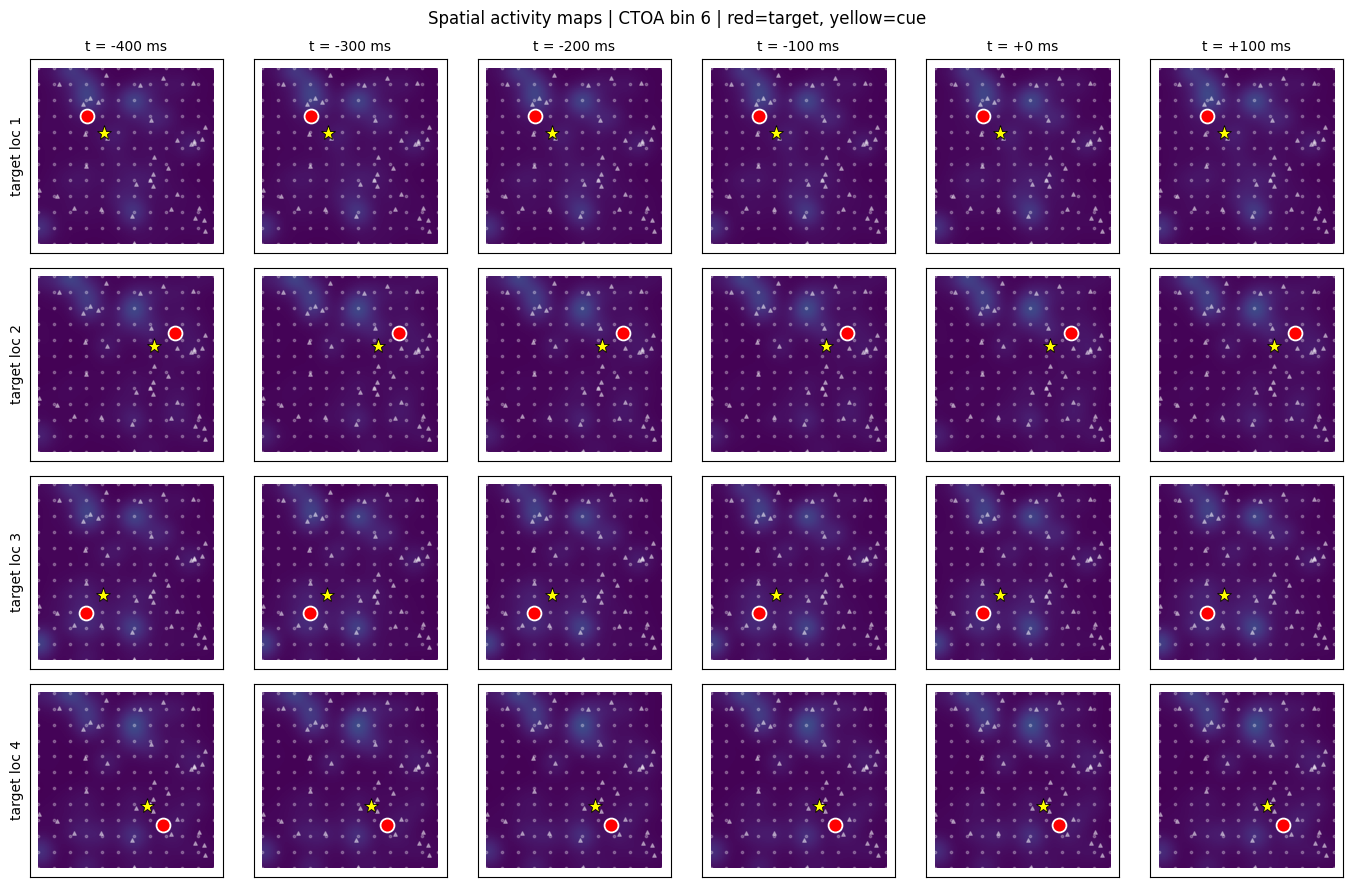

In [3]:
def smooth_map(vals, pts, grid_size=80, sigma=0.12):
    """vals [H], pts [H,2] in [-1,+1]^2 -> smooth [grid, grid]"""
    gx = np.linspace(-1, 1, grid_size)
    gy = np.linspace(-1, 1, grid_size)
    GX, GY = np.meshgrid(gx, gy)
    Z = np.zeros_like(GX)
    for i in range(len(vals)):
        d2 = (GX - pts[i, 0]) ** 2 + (GY - pts[i, 1]) ** 2
        Z += vals[i] * np.exp(-d2 / (2 * sigma**2))
    return Z


W_BEFORE = 25  # 500 ms pre-target at dt=20
W_AFTER = 10  # 200 ms post-target
snapshot_ts = np.array([-20, -15, -10, -5, 0, 5])  # timesteps re target
snapshot_ms = snapshot_ts * DT

fig, axes = plt.subplots(
    4, len(snapshot_ts), figsize=(2.3 * len(snapshot_ts), 9), sharex=True, sharey=True
)

for row, tgt_loc in enumerate([1, 2, 3, 4]):
    loc_trials = [tr for tr in rep_trials if tr["target_loc"] == tgt_loc]
    if len(loc_trials) < 3:
        for col in range(len(snapshot_ts)):
            axes[row, col].set_visible(False)
        continue

    segs = []
    for tr in loc_trials:
        t0 = tr["target_onset"]
        h = tr["h"]
        s, e = t0 - W_BEFORE, t0 + W_AFTER + 1
        if s < 0 or e > len(h):
            continue
        segs.append(h[s:e])
    seg_mean = np.stack(segs).mean(axis=0)  # [W, H]
    relu = np.clip(seg_mean, 0, None)
    vmax = float(relu.max()) if relu.max() > 0 else 1.0

    for col, (ts, ms) in enumerate(zip(snapshot_ts, snapshot_ms)):
        idx = W_BEFORE + ts
        h_t = relu[idx]
        Z = smooth_map(h_t, coords, sigma=0.12)
        ax = axes[row, col]
        ax.imshow(
            Z,
            origin="lower",
            extent=[-1, 1, -1, 1],
            cmap="viridis",
            vmin=0,
            vmax=vmax * coords.shape[0] * 0.03,
        )
        # neuron positions (faint)
        ax.scatter(coords[:n_exc, 0], coords[:n_exc, 1], s=3, c="white", alpha=0.25)
        ax.scatter(
            coords[n_exc:, 0], coords[n_exc:, 1], s=6, c="white", marker="^", alpha=0.4
        )
        # target + cue markers (mean position across the bucket of trials)
        tx, ty = np.mean([tr["target_pos"] for tr in loc_trials], axis=0)
        cx, cy = np.mean([tr["cue_pos"] for tr in loc_trials], axis=0)
        ax.plot(tx, ty, "o", mfc="red", mec="white", mew=1.3, markersize=10)
        ax.plot(cx, cy, "*", mfc="yellow", mec="black", mew=0.6, markersize=11)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"t = {int(ms):+d} ms", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"target loc {tgt_loc}", fontsize=10)

fig.suptitle(
    f"Spatial activity maps | CTOA bin {rep_bin} | " f"red=target, yellow=cue",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("../figures/spatial_activity_map.png", dpi=140)
plt.show()

## 3. Linear decoder `h(t) -> (tx, ty)` — honest version

Previous version had a bug: "fixation baseline" used `target_onset - 600ms`,
which is INSIDE cue/delay for long-CTOA trials and contains full cue info.

Here we align by **cue onset** instead — this gives a clean pre-cue window
(guaranteed fixation epoch, since fixation duration ∈ [700, 1200] ms).

Decoder: Ridge(alpha=1.0), 5-fold CV, R² on continuous (tx, ty).
Baselines:
- **shuffled targets** — null, R² should hover around 0
- **pre-cue** — h at `cue_onset - 200ms`, deep in fixation → target not
  yet determined in h (should be R² ≈ 0 if properly pre-cue)

Interpretation:
- If R² jumps from 0 to high **at cue onset** → network encodes cue identity
  (categorical memory, not spatial drift)
- If R² rises gradually through delay → genuine spatial evolution

Cue-aligned h: (590, 101, 180)
True pre-cue (t = -200 ms rel cue) R² = -0.011


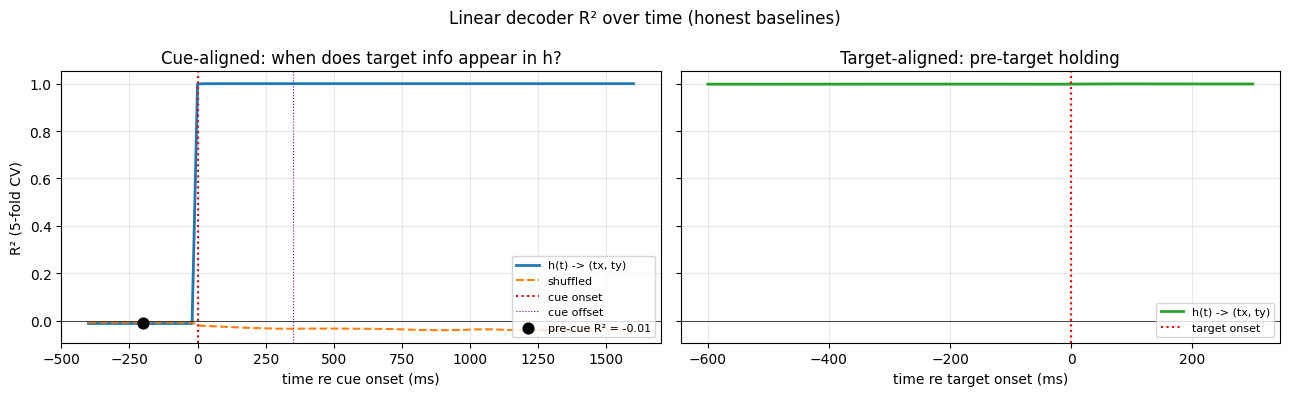


=== Leave-one-corner-out generalization test ===
(If the code is geometric, decoder trained on 3 corners predicts
 the 4th well. If it is discrete/categorical, it fails.)
  held-out corner 1 (true=[-0.44780768  0.43757076]): mean pred = [-0.412, +0.432]  err = 0.036
  held-out corner 2 (true=[0.46379257 0.43579325]): mean pred = [+0.481, +0.452]  err = 0.023
  held-out corner 3 (true=[-0.46958739 -0.42592293]): mean pred = [-0.438, -0.410]  err = 0.036
  held-out corner 4 (true=[ 0.45834667 -0.42791982]): mean pred = [+0.469, -0.427]  err = 0.011


In [4]:
def cv_r2(X, y, k=5, seed=0):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    r2s = []
    for tr_ix, te_ix in kf.split(X):
        clf = Ridge(alpha=1.0)
        clf.fit(X[tr_ix], y[tr_ix])
        r2s.append(clf.score(X[te_ix], y[te_ix]))
    return float(np.mean(r2s)), float(np.std(r2s) / np.sqrt(k))


# Cue-onset alignment
# Cover from -400 ms (pre-cue fixation) through cue + 1500 ms delay
CB, CA = 20, 80  # -400 ms .. +1600 ms rel cue onset
cue_aligned_h, cue_aligned_xy = [], []
for tr in corr:
    t0 = tr["cue_onset"]
    h = tr["h"]
    T = len(h)
    s, e = t0 - CB, t0 + CA + 1
    if s < 0 or e > T:
        continue
    cue_aligned_h.append(h[s:e])
    tx, ty = tr["target_pos"]
    cue_aligned_xy.append([tx, ty])
cue_aligned_h = np.stack(cue_aligned_h, axis=0)
cue_aligned_xy = np.array(cue_aligned_xy)
cue_ms = np.arange(-CB, CA + 1) * DT
print(f"Cue-aligned h: {cue_aligned_h.shape}")

r2_cue = np.zeros(cue_aligned_h.shape[1])
sem_cue = np.zeros_like(r2_cue)
for t in range(cue_aligned_h.shape[1]):
    r2_cue[t], sem_cue[t] = cv_r2(cue_aligned_h[:, t, :], cue_aligned_xy)

rng = np.random.default_rng(0)
xy_shuf = cue_aligned_xy[rng.permutation(len(cue_aligned_xy))]
r2_shuf = np.zeros_like(r2_cue)
for t in range(cue_aligned_h.shape[1]):
    r2_shuf[t], _ = cv_r2(cue_aligned_h[:, t, :], xy_shuf)

# True pre-cue baseline: -200 ms rel cue onset (index = CB - 10)
pre_cue_idx = CB - 10
r2_precue, _ = cv_r2(cue_aligned_h[:, pre_cue_idx, :], cue_aligned_xy)
print(f"True pre-cue (t = -200 ms rel cue) R² = {r2_precue:+.3f}")

# Target-onset alignment
WB, WA = 30, 15
t_aligned_h, t_aligned_xy = [], []
for tr in corr:
    t0 = tr["target_onset"]
    h = tr["h"]
    T = len(h)
    s, e = t0 - WB, t0 + WA + 1
    if s < 0 or e > T:
        continue
    t_aligned_h.append(h[s:e])
    tx, ty = tr["target_pos"]
    t_aligned_xy.append([tx, ty])
t_aligned_h = np.stack(t_aligned_h, axis=0)
t_aligned_xy = np.array(t_aligned_xy)
tgt_ms = np.arange(-WB, WA + 1) * DT
r2_tgt = np.zeros(t_aligned_h.shape[1])
sem_tgt = np.zeros_like(r2_tgt)
for t in range(t_aligned_h.shape[1]):
    r2_tgt[t], sem_tgt[t] = cv_r2(t_aligned_h[:, t, :], t_aligned_xy)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

ax = axes[0]
ax.fill_between(cue_ms, r2_cue - sem_cue, r2_cue + sem_cue, alpha=0.25, color="C0")
ax.plot(cue_ms, r2_cue, "C0-", lw=2, label="h(t) -> (tx, ty)")
ax.plot(cue_ms, r2_shuf, "C1--", lw=1.5, label="shuffled")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="red", ls=":", label="cue onset")
ax.axvline(350, color="purple", ls=":", lw=0.8, label="cue offset")
ax.scatter(
    [-200], [r2_precue], color="k", s=60, zorder=5, label=f"pre-cue R² = {r2_precue:+.2f}"
)
ax.set_xlabel("time re cue onset (ms)")
ax.set_ylabel("R² (5-fold CV)")
ax.set_title("Cue-aligned: when does target info appear in h?")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.fill_between(tgt_ms, r2_tgt - sem_tgt, r2_tgt + sem_tgt, alpha=0.25, color="C2")
ax.plot(tgt_ms, r2_tgt, "C2-", lw=2, label="h(t) -> (tx, ty)")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="red", ls=":", label="target onset")
ax.set_xlabel("time re target onset (ms)")
ax.set_title("Target-aligned: pre-target holding")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("Linear decoder R² over time (honest baselines)")
fig.tight_layout()
fig.savefig("../figures/spatial_decoder.png", dpi=140)
plt.show()

# Geometric vs categorical test: decoder trained on 3 corners should predict
# the 4th well if the code is spatial/continuous; fails if it is discrete/one-hot.
print()
print("=== Leave-one-corner-out generalization test ===")
print("(If the code is geometric, decoder trained on 3 corners predicts")
print(" the 4th well. If it is discrete/categorical, it fails.)")

test_t_idx = CB + 20
X = cue_aligned_h[:, test_t_idx, :]
y = cue_aligned_xy
corner_of = []
for tr in corr:
    t0 = tr["cue_onset"]
    h = tr["h"]
    T = len(h)
    s, e = t0 - CB, t0 + CA + 1
    if s < 0 or e > T:
        continue
    corner_of.append(tr["target_loc"])
corner_of = np.array(corner_of)

for held_out in [1, 2, 3, 4]:
    tr_mask = corner_of != held_out
    te_mask = corner_of == held_out
    if te_mask.sum() == 0:
        continue
    clf = Ridge(alpha=1.0)
    clf.fit(X[tr_mask], y[tr_mask])
    y_te = y[te_mask]
    y_pred = clf.predict(X[te_mask])
    mean_pred = y_pred.mean(axis=0)
    mean_true = y_te.mean(axis=0)
    err = np.linalg.norm(mean_pred - mean_true)
    print(
        f"  held-out corner {held_out} (true={mean_true}): "
        f"mean pred = [{mean_pred[0]:+.3f}, {mean_pred[1]:+.3f}]  "
        f"err = {err:.3f}"
    )

## 4. Center of mass + spatial variance

Weighted COM across all 180 neurons: `com = Σᵢ relu(hᵢ) · rᵢ / Σᵢ relu(hᵢ)`.
Spatial variance: weighted mean squared distance from COM.

If the network is spatial, COM should move from cue location toward target, and
variance should drop as activity focuses onto target.

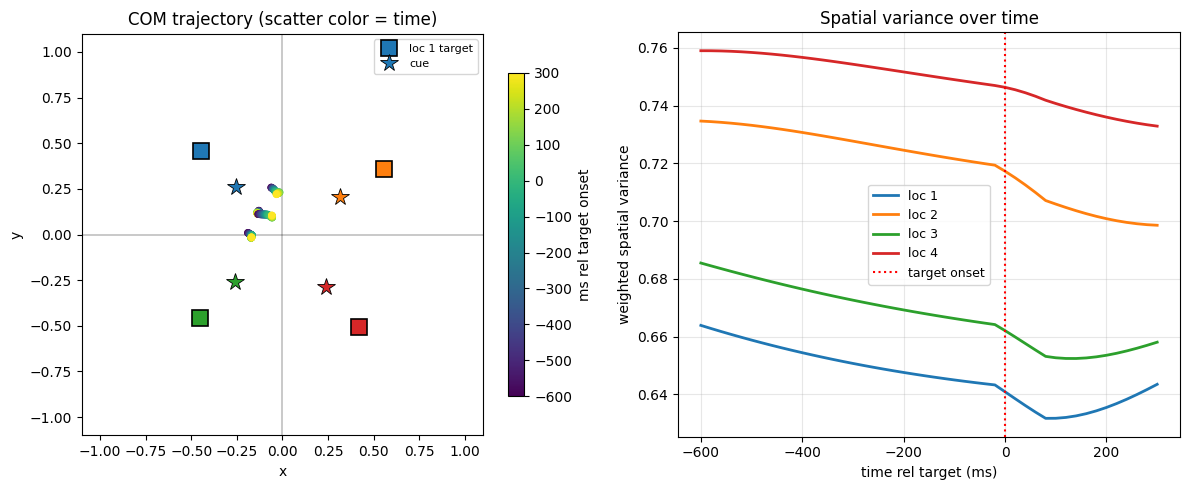

In [5]:
def com_and_var(h_seq, coords):
    """h_seq [T, H], coords [H, 2] -> com [T, 2], var [T]"""
    w = np.clip(h_seq, 0, None)  # [T, H]
    s = w.sum(axis=1, keepdims=True)
    s = np.where(s > 0, s, 1.0)
    com = (w @ coords) / s  # [T, 2]
    diff = coords[None, :, :] - com[:, None, :]  # [T, H, 2]
    d2 = (diff**2).sum(axis=-1)  # [T, H]
    var = (w * d2).sum(axis=1) / s[:, 0]  # [T]
    return com, var


# time axis for the [t0-WB, t0+WA] window (relative to target onset, in ms)
rel_ms = np.arange(-WB, WA + 1) * DT

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["C0", "C1", "C2", "C3"]
var_curves = {}

for loc in [1, 2, 3, 4]:
    tr_set = [tr for tr in corr if tr["target_loc"] == loc and tr["ctoa_bin"] == rep_bin]
    if len(tr_set) < 3:
        continue
    coms, vars_ = [], []
    for tr in tr_set:
        t0 = tr["target_onset"]
        h = tr["h"]
        s, e = t0 - WB, t0 + WA + 1
        if s < 0 or e > len(h):
            continue
        c, v = com_and_var(h[s:e], coords)
        coms.append(c)
        vars_.append(v)
    com_m = np.mean(np.stack(coms), axis=0)  # [W, 2]
    var_m = np.mean(np.stack(vars_), axis=0)  # [W]
    var_curves[loc] = var_m

    ax = axes[0]
    sc = ax.scatter(com_m[:, 0], com_m[:, 1], c=rel_ms, cmap="viridis", s=20, zorder=3)
    ax.plot(com_m[:, 0], com_m[:, 1], color=colors[loc - 1], lw=1.0, alpha=0.6, zorder=2)
    # marker positions = mean of trial positions in this quadrant bucket
    tx, ty = np.mean([tr["target_pos"] for tr in tr_set], axis=0)
    cx, cy = np.mean([tr["cue_pos"] for tr in tr_set], axis=0)
    ax.plot(
        tx,
        ty,
        "s",
        color=colors[loc - 1],
        mec="k",
        markersize=11,
        mew=1.2,
        zorder=4,
        label=f"loc {loc} target" if loc == 1 else None,
    )
    ax.plot(
        cx,
        cy,
        "*",
        color=colors[loc - 1],
        mec="k",
        markersize=13,
        mew=0.6,
        zorder=4,
        label="cue" if loc == 1 else None,
    )

axes[0].set_xlim(-1.1, 1.1)
axes[0].set_ylim(-1.1, 1.1)
axes[0].axhline(0, color="k", lw=0.3)
axes[0].axvline(0, color="k", lw=0.3)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("COM trajectory (scatter color = time)")
axes[0].legend(fontsize=8, loc="upper right")
plt.colorbar(sc, ax=axes[0], label="ms rel target onset", shrink=0.8)

ax = axes[1]
for loc, vc in var_curves.items():
    ax.plot(rel_ms, vc, color=colors[loc - 1], lw=2, label=f"loc {loc}")
ax.axvline(0, color="red", ls=":", label="target onset")
ax.set_xlabel("time rel target (ms)")
ax.set_ylabel("weighted spatial variance")
ax.set_title("Spatial variance over time")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/com_variance.png", dpi=140)
plt.show()

## 5. Spatial ablation

For each trial: silence k=20 neurons and measure hit rate. Compare:
- **baseline** (no ablation)
- **near target** — k nearest to `(tx, ty)`
- **far from target** — k farthest from `(tx, ty)`
- **random** — k random neurons

If the network uses space, *near-target* ablation should hurt most, *far* and
*random* less. If all are equally harmful, the task is solved by identity code,
not spatial code.

Ablation = multiply hidden state by mask after every `model.step()` so the
silenced neurons can't influence downstream dynamics.

Running ablation (may take ~1-2 min)...
  baseline       : hit =  98.3% ±  1.6%
  near target    : hit =   1.3% ±  0.8%
  far target     : hit =  34.5% ±  6.6%
  random         : hit =  10.0% ±  1.6%


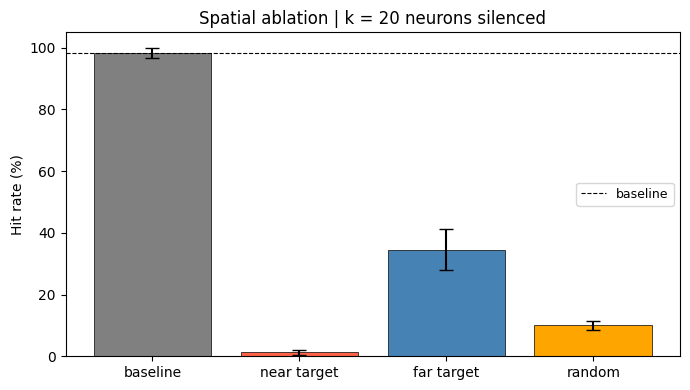

In [6]:
@torch.no_grad()
def rollout_on_reset_env(model, env, keep_mask):
    """env must already be .reset(). Returns outcome string."""
    x = env.ob.astype(np.float32)
    gt = env.gt.astype(np.int64)
    xb = torch.tensor(x, device=device).unsqueeze(0)  # [1, T, 7]
    h = model.init_hidden(1, xb.device)
    mask = torch.tensor(keep_mask, dtype=torch.float32, device=xb.device).view(1, -1)
    logits_list = []
    for t in range(xb.shape[1]):
        h, y = model.step(xb[:, t, :], h)
        h = h * mask
        logits_list.append(y)
    logits = torch.stack(logits_list, dim=1)[0].cpu().numpy()
    actions = np.argmax(logits, axis=-1)
    first = np.where(actions == 1)[0]
    if len(first) == 0:
        return "miss"
    t_first = int(first[0])
    return "correct" if gt[t_first] == 1 else "fa_or_abort"


K = 20


def mask_none(tx, ty, rng):
    return np.ones(H, dtype=np.float32)


def mask_near(tx, ty, rng):
    d = np.linalg.norm(coords - np.array([tx, ty]), axis=1)
    ix = np.argsort(d)[:K]
    m = np.ones(H, dtype=np.float32)
    m[ix] = 0.0
    return m


def mask_far(tx, ty, rng):
    d = np.linalg.norm(coords - np.array([tx, ty]), axis=1)
    ix = np.argsort(d)[-K:]
    m = np.ones(H, dtype=np.float32)
    m[ix] = 0.0
    return m


def mask_random(tx, ty, rng):
    ix = rng.choice(H, size=K, replace=False)
    m = np.ones(H, dtype=np.float32)
    m[ix] = 0.0
    return m


def run_ablation(mask_builder, n_trials=120, seeds=(0, 1, 2, 3, 4)):
    accs = []
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        rng = np.random.default_rng(seed)
        hits = 0
        total = 0
        for _ in range(n_trials):
            env = make_env_eval()
            env.reset()
            tx, ty = env.trial["target_pos"]
            m = mask_builder(tx, ty, rng)
            outcome = rollout_on_reset_env(model, env, m)
            if outcome == "correct":
                hits += 1
            total += 1
        accs.append(hits / total)
    return float(np.mean(accs)), float(np.std(accs))


print("Running ablation (may take ~1-2 min)...")
results = {}
for name, fn in [
    ("baseline", mask_none),
    ("near target", mask_near),
    ("far target", mask_far),
    ("random", mask_random),
]:
    mu, sd = run_ablation(fn, n_trials=120, seeds=(0, 1, 2, 3, 4))
    results[name] = (mu, sd)
    print(f"  {name:15s}: hit = {100*mu:5.1f}% ± {100*sd:4.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
names = list(results.keys())
mus = [results[n][0] * 100 for n in names]
sds = [results[n][1] * 100 for n in names]
bar_colors = ["gray", "tomato", "steelblue", "orange"]
ax.bar(
    names, mus, yerr=sds, capsize=5, color=bar_colors, edgecolor="black", linewidth=0.5
)
ax.axhline(results["baseline"][0] * 100, color="k", ls="--", lw=0.8, label="baseline")
ax.set_ylabel("Hit rate (%)")
ax.set_title(f"Spatial ablation | k = {K} neurons silenced")
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../figures/ablation_bars.png", dpi=140)
plt.show()

## 6. Sanity: post-target map should peak at target

If this fails, the other analyses are meaningless. The combined activity map at
`target_onset + 100 ms` should clearly localize at the target position.

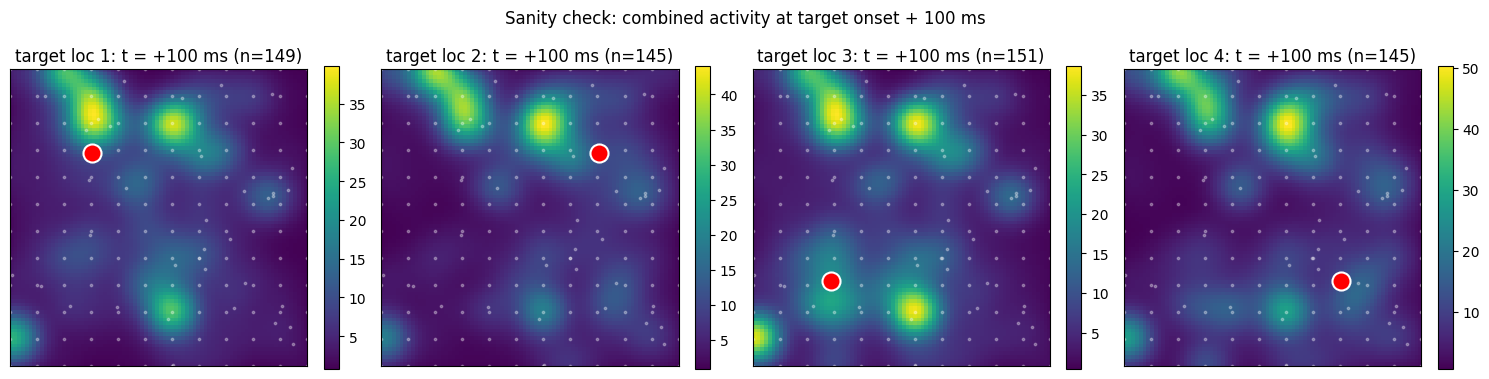

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for col, loc in enumerate([1, 2, 3, 4]):
    tr_set = [tr for tr in corr if tr["target_loc"] == loc]
    if len(tr_set) < 3:
        axes[col].set_title(f"loc {loc}: no data")
        continue
    h_sum = np.zeros(H)
    n = 0
    for tr in tr_set:
        t0 = tr["target_onset"]
        h = tr["h"]
        idx = t0 + 5  # +100 ms at dt=20
        if idx >= len(h):
            continue
        h_sum += np.clip(h[idx], 0, None)
        n += 1
    h_mean = h_sum / max(n, 1)
    Z = smooth_map(h_mean, coords, sigma=0.12)
    ax = axes[col]
    im = ax.imshow(Z, origin="lower", extent=[-1, 1, -1, 1], cmap="viridis")
    ax.scatter(coords[:, 0], coords[:, 1], s=3, c="white", alpha=0.3)
    tx, ty = np.mean([tr["target_pos"] for tr in tr_set], axis=0)
    ax.plot(tx, ty, "o", mfc="red", mec="white", mew=1.5, markersize=13)
    ax.set_title(f"target loc {loc}: t = +100 ms (n={n})")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Sanity check: combined activity at target onset + 100 ms")
fig.tight_layout()
fig.savefig("../figures/sanity_post_target.png", dpi=140)
plt.show()

## Summary / verdict template

Fill in after running. Adjudicate each test:

| Test                               | Result       | Spatial? |
| ---------------------------------- | ------------ | -------- |
| 1. Activity maps show drift toward target | ?          | ?        |
| 2. Decoder R² rises to ~0.5+ near target  | ?          | ?        |
| 3. COM moves cue → target; variance drops | ?          | ?        |
| 4. Near-target ablation >> random/far     | ?          | ?        |
| **Sanity**: post-target peak at target    | **must be yes** | —    |

**Interpretation:**
- 4/4 yes → strong continuous spatial code
- 2–3 yes → partial spatial structure on top of discrete attractors
- 0–1 yes → network solves the task without using geometry (4-way categorical).
  In that case the Gaussian RF input is present but the recurrent dynamics
  collapsed it to corner-ID memory. To force spatial coding: add continuous
  target locations, or make `target_loc != cue_loc` with a geometric relation.
